<div align="center">

# ✨ Sephora Products Analysis ✨

<img src="image.jpg" width="500">

## 💄 Beauty • Reviews • Trends • Analytics 💄

</div>

In [ ]:
# Instalación de las bibliotecas necesarias para el análisis de datos y conexión a MySQL
!pip install pandas jupyter mysql-connector-python


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
# Importar la biblioteca pandas para el manejo de datos
import pandas as pd

In [ ]:
# Importar el conector de MySQL para la conexión con la base de datos
import mysql.connector

In [ ]:
# Imprimir la configuración de MySQL para verificar los datos de conexión
print(mysql_config)

{'host': 'gateway01.eu-central-1.prod.aws.tidbcloud.com', 'port': 4000, 'user': 'xK9KJXfWsncFqjX.root', 'password': 'RvViMsZXM8evWUvy', 'database': 'proyecto_sephora', 'ssl_disabled': False}


In [ ]:
# Importar las credenciales de configuración de MySQL desde un archivo externo
from credenciales import mysql_config

In [ ]:
# Leer el archivo CSV con información de productos
products = pd.read_csv("productsinfo.csv")

In [ ]:
# Leer los archivos CSV con información de reseñas y concatenarlos en un solo DataFrame
reviews_a = pd.read_csv("reviewsA.csv")
reviews_b = pd.read_csv("reviewsB.csv")
reviews_c = pd.read_csv("reviewsC.csv")

/var/folders/xd/rwrzkc9j1qvf__902tz_fcd00000gn/T/ipykernel_2950/3420278249.py:1: DtypeWarning: Columns (0: author_id) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews_a = pd.read_csv("reviewsA.csv")
/var/folders/xd/rwrzkc9j1qvf__902tz_fcd00000gn/T/ipykernel_2950/3420278249.py:3: DtypeWarning: Columns (0: author_id) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews_c = pd.read_csv("reviewsC.csv")


In [ ]:
# Combinar todas las reseñas en un único DataFrame
reviews = pd.concat([reviews_a, reviews_b, reviews_c], ignore_index=True)

In [ ]:
# Mostrar las primeras filas del DataFrame de productos para inspección
products.head()

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


In [ ]:
# Filtrar las columnas relevantes del DataFrame de productos
products = products[
    [
        "product_id",
        "product_name",
        "brand_id",
        "brand_name",
        "loves_count",
        "rating",
        "reviews",
        "price_usd",
        "primary_category",
        "secondary_category",
        "tertiary_category",
        "sephora_exclusive"
    ]
]

In [ ]:
# Verificar nuevamente las primeras filas del DataFrame filtrado
products.head()

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,price_usd,primary_category,secondary_category,tertiary_category,sephora_exclusive
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,35.0,Fragrance,Value & Gift Sets,Perfume Gift Sets,0
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,195.0,Fragrance,Women,Perfume,0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,195.0,Fragrance,Women,Perfume,0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,195.0,Fragrance,Women,Perfume,0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,195.0,Fragrance,Women,Perfume,0


In [ ]:
# Verificar la cantidad de valores nulos en el DataFrame de productos
products.isnull().sum()

product_id              0
product_name            0
brand_id                0
brand_name              0
loves_count             0
rating                278
reviews               278
price_usd               0
primary_category        0
secondary_category      8
tertiary_category     990
sephora_exclusive       0
dtype: int64

In [ ]:
# Mostrar las primeras filas de cada DataFrame de reseñas para inspección
reviews_a.head()
reviews_b.head()
reviews_c.head()

,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,8554483509,2,0.0,NaN,0,0,0,2023-03-21,This was gifted by Supergoop! in exchange for ...,Nice packaging but easy to overuse,light,brown,combination,NaN,P467976,(Re)setting 100% Mineral Powder Sunscreen SPF ...,Supergoop!,35.0
1,1,24710523057,2,0.0,1.000000,2,0,2,2023-03-07,I didn’t like it; too much product comes out w...,Packaging is not suits le,NaN,brown,combination,NaN,P467976,(Re)setting 100% Mineral Powder Sunscreen SPF ...,Supergoop!,35.0
2,2,8429283179,5,1.0,0.941176,34,2,32,2023-03-01,Y’all….I’m begging for everyone to read instru...,PLS READ THIS LOL,light,green,normal,brown,P467976,(Re)setting 100% Mineral Powder Sunscreen SPF ...,Supergoop!,35.0
3,3,8105185455,1,0.0,0.000000,5,5,0,2023-02-27,I have not figured out how to use this product...,At a loss,tan,brown,combination,black,P467976,(Re)setting 100% Mineral Powder Sunscreen SPF ...,Supergoop!,35.0
4,4,1515931062,1,0.0,0.000000,7,7,0,2023-02-27,I’m at a loss as to how to use this thing!!! C...,NOT for me!!,fair,blue,combination,blonde,P467976,(Re)setting 100% Mineral Powder Sunscreen SPF ...,Supergoop!,35.0


In [ ]:
# Filtrar las columnas relevantes del DataFrame de reseñas
reviews = reviews[
    [
        "author_id",
        "rating",
        "is_recommended",
        "helpfulness",
        "submission_time",
        "review_text",
        "review_title",
        "skin_tone",
        "eye_color",
        "skin_type",
        "hair_color",
        "product_id"
    ]
]

In [ ]:
# Mostrar las primeras filas del DataFrame de reseñas filtrado
reviews.head()

,author_id,rating,is_recommended,helpfulness,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id
0,1741593524,5,1.0,1.0,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322
1,31423088263,1,0.0,NaN,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652
2,5061282401,5,1.0,NaN,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652
3,6083038851,5,1.0,NaN,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652
4,47056667835,5,1.0,NaN,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652


In [ ]:
# Verificar la cantidad de valores nulos en el DataFrame de reseñas
reviews.isnull().sum()

author_id               0
rating                  0
is_recommended     152368
helpfulness        491713
submission_time         0
review_text          1260
review_title       262295
skin_tone          148103
eye_color          186925
skin_type           99037
hair_color         198182
product_id              0
dtype: int64

In [63]:
# Función para cargar un DataFrame en una tabla de MySQL en lotes
# Permite manejar grandes volúmenes de datos de manera eficiente
def cargar_csv_en_tabla(df, tabla, conn, batch=1000):
    cursor = conn.cursor()
    cols = ", ".join(df.columns)
    placeholders = ", ".join(["%s"] * len(df.columns))
    sql = f"INSERT INTO {tabla} ({cols}) VALUES ({placeholders})"
    filas = [
        tuple(None if pd.isna(v) else v for v in row)
        for row in df.itertuples(index=False, name=None)
    ]
    for i in range(0, len(filas), batch):
        cursor.executemany(sql, filas[i:i+batch])
        conn.commit()
        print(f"Insertadas {min(i+batch, len(filas))}/{len(filas)} filas")
    cursor.close()

In [ ]:
# Establecer conexión con la base de datos MySQL
conn = mysql.connector.connect(**mysql_config)

In [ ]:
# Convertir la columna 'submission_time' a formato datetime para análisis temporal
reviews["submission_time"] = pd.to_datetime(
    reviews["submission_time"],
    errors="coerce"
)

In [64]:
# Cargar los datos en las tablas de MySQL (solo ejecutar una vez)
# Los datos ya fueron cargados previamente en TiDB Cloud
# cargar_csv_en_tabla(products, "products", conn)
# cargar_csv_en_tabla(reviews, "reviews", conn)

In [ ]:
# Cerrar la conexión con la base de datos
conn.close()

In [ ]:
# Reabrir la conexión con la base de datos MySQL
conn = mysql.connector.connect(**mysql_config)

In [ ]:
# Definir la consulta SQL para unir productos y reseñas
query = """
SELECT
    p.product_id,
    p.product_name,
    p.brand_name,
    p.price_usd,
    p.primary_category,
    p.secondary_category,
    p.tertiary_category,
    p.sephora_exclusive,
    p.rating AS product_rating,
    p.loves_count,
    r.author_id,
    r.rating AS review_rating,
    r.is_recommended,
    r.helpfulness,
    r.submission_time,
    r.review_text,
    r.review_title,
    r.skin_tone,
    r.eye_color,
    r.skin_type,
    r.hair_color
FROM products p
JOIN reviews r
ON p.product_id = r.product_id
"""

In [ ]:
# Ejecutar la consulta SQL y cargar los datos en un DataFrame de pandas
df = pd.read_sql(query, conn)

/var/folders/xd/rwrzkc9j1qvf__902tz_fcd00000gn/T/ipykernel_2950/1168034203.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [ ]:
# Cerrar la conexión con la base de datos después de ejecutar la consulta
conn.close()

In [ ]:
# Mostrar las primeras filas del DataFrame resultante para inspección
df.head()

,product_id,product_name,brand_name,price_usd,primary_category,secondary_category,tertiary_category,sephora_exclusive,product_rating,loves_count,...,review_rating,is_recommended,helpfulness,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color
0,P500472,Mini Plum Plump Hyaluronic Acid Moisturizer,Glow Recipe,21.0,Skincare,Mini Size,NaN,1,4.462,26404,...,5.0,1.0,NaN,2023-03-21,This literally saved my skin. It was always so...,If I could marry this moisturizer I would,fair,gray,dry,blonde
1,P500472,Mini Plum Plump Hyaluronic Acid Moisturizer,Glow Recipe,21.0,Skincare,Mini Size,NaN,1,4.462,26404,...,5.0,1.0,NaN,2023-03-21,Amazing product. My skin feels amazing after t...,NaN,fair,blue,normal,brown
2,P500472,Mini Plum Plump Hyaluronic Acid Moisturizer,Glow Recipe,21.0,Skincare,Mini Size,NaN,1,4.462,26404,...,5.0,1.0,1.0,2023-03-20,I love this moisturizer! I was using both the ...,NaN,light,hazel,dry,brown
3,P500472,Mini Plum Plump Hyaluronic Acid Moisturizer,Glow Recipe,21.0,Skincare,Mini Size,NaN,1,4.462,26404,...,2.0,0.0,0.5,2023-03-18,"Very creamy and feels wonderful; HOWEVER, you ...",Leave in the store,light,green,combination,blonde
4,P500472,Mini Plum Plump Hyaluronic Acid Moisturizer,Glow Recipe,21.0,Skincare,Mini Size,NaN,1,4.462,26404,...,5.0,1.0,NaN,2023-03-17,This product worked really good. Just took a w...,Got to have it,lightMedium,brown,oily,brown


In [ ]:
# Guardar el DataFrame en un archivo Parquet para análisis posterior
df.to_parquet("sephora_analytics_dataset.parquet")

In [ ]:
# Verificar los tipos de datos de las columnas del DataFrame
df.dtypes

product_id                       str
product_name                     str
brand_name                       str
price_usd                    float64
primary_category                 str
secondary_category               str
tertiary_category                str
sephora_exclusive              int64
product_rating               float64
loves_count                    int64
author_id                        str
review_rating                float64
is_recommended               float64
helpfulness                  float64
submission_time       datetime64[us]
review_text                      str
review_title                     str
skin_tone                        str
eye_color                        str
skin_type                        str
hair_color                       str
dtype: object

In [ ]:
# Verificar la cantidad de valores nulos en el DataFrame final
df.isnull().sum()

product_id                 0
product_name               0
brand_name                 0
price_usd                  0
primary_category           0
secondary_category         0
tertiary_category     173865
sephora_exclusive          0
product_rating             0
loves_count                0
author_id                  0
review_rating              0
is_recommended        159970
helpfulness           513612
submission_time            0
review_text             1376
review_title          272989
skin_tone             155447
eye_color             196182
skin_type             104383
hair_color            207430
dtype: int64

In [ ]:
# Eliminar filas con valores nulos en la columna 'review_text'
df = df.dropna(subset=["review_text"])

In [ ]:
# Verificar la cantidad de filas duplicadas en el DataFrame
df.duplicated().sum()

np.int64(39086)

In [ ]:
# Eliminar filas duplicadas del DataFrame
df = df.drop_duplicates()

In [ ]:
# Verificar nuevamente la cantidad de filas duplicadas después de eliminarlas
df.duplicated().sum()

np.int64(0)

In [ ]:
# Verificar nuevamente la cantidad de valores nulos en el DataFrame
df.isnull().sum()

product_id                 0
product_name               0
brand_name                 0
price_usd                  0
primary_category           0
secondary_category         0
tertiary_category     146460
sephora_exclusive          0
product_rating             0
loves_count                0
author_id                  0
review_rating              0
is_recommended        152299
helpfulness           490686
submission_time            0
review_text                0
review_title          261001
skin_tone             148006
eye_color             186799
skin_type              98942
hair_color            198069
dtype: int64

In [ ]:
# Crear nuevas columnas para análisis temporal a partir de 'submission_time'
df["year"] = df["submission_time"].dt.year
df["month"] = df["submission_time"].dt.month
df["day_name"] = df["submission_time"].dt.day_name()

In [ ]:
# Identificar productos con precios negativos para validación de datos
df[df["price_usd"] < 0]

,product_id,product_name,brand_name,price_usd,primary_category,secondary_category,tertiary_category,sephora_exclusive,product_rating,loves_count,...,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,year,month,day_name


In [65]:
# Recalcular columnas temporales para análisis de tendencias
df["year"] = df["submission_time"].dt.year
df["month"] = df["submission_time"].dt.month
df["day_name"] = df["submission_time"].dt.day_name()

<h1 style="text-align:center; color:#FF69B4;">
💄 Sephora Products Analysis ✨
</h1>

<h3 style="text-align:center;">
Exploratory Data Analysis of Sephora Product Reviews
</h3>

1. ¿Cómo son los productos skincare de Sephora?
2. ¿Qué productos destacan más?
3. ¿Cómo reaccionan los usuarios a esos productos?

<h2 style="color:#C71585;">
📊 General Overview
</h2>

In [ ]:
# Verificar la forma (dimensiones) del DataFrame
df.shape

(926710, 24)

In [ ]:
# Listar las columnas disponibles en el DataFrame
df.columns

Index(['product_id', 'product_name', 'brand_name', 'price_usd',
       'primary_category', 'secondary_category', 'tertiary_category',
       'sephora_exclusive', 'product_rating', 'loves_count', 'author_id',
       'review_rating', 'is_recommended', 'helpfulness', 'submission_time',
       'review_text', 'review_title', 'skin_tone', 'eye_color', 'skin_type',
       'hair_color', 'year', 'month', 'day_name'],
      dtype='str')

In [ ]:
# Contar el número de productos únicos en el DataFrame
df["product_name"].nunique()

995

In [ ]:
# Contar la cantidad de reseñas por producto para identificar los más populares
df["product_name"].value_counts()

product_name
Lip Sleeping Mask Intense Hydration with Vitamin C      16071
Soy Hydrating Gentle Face Cleanser                       8728
100 percent Pure Argan Oil                               7760
Ultra Repair Cream Intense Hydration                     7538
Alpha Beta Extra Strength Daily Peel Pads                7326
                                                        ...  
EUK 134 0.1%                                              140
Weightless Oil-Free Moisturizer                           140
Vinopure Oil-Control Moisturizer for Acne Prone Skin      139
Hydro Ungrip Makeup Remover + Cleansing Water             139
Gentle Hydra-Gel Face Cleanser                              1
Name: count, Length: 995, dtype: int64

In [ ]:
# Identificar el rango de fechas de las reseñas realizadas para análisis temporal
df["submission_time"].min(),
df["submission_time"].max()

Timestamp('2023-03-21 00:00:00')

El dataset contiene información sobre productos y reseñas de Sephora, incluyendo precios, categorías, ratings y métricas de interacción de clientes.

<h2 style="color:#FF1493;">
💵 Precios de los Productos Skincare
</h2>

Pregunta:
¿La mayoría de productos Sephora son accesibles o premium?

In [ ]:
# Analizar la distribución de precios de los productos para entender el rango de precios
df["price_usd"].describe()

count    926710.000000
mean         47.935016
std          36.839413
min           3.000000
25%          24.000000
50%          39.000000
75%          62.000000
max         410.000000
Name: price_usd, dtype: float64

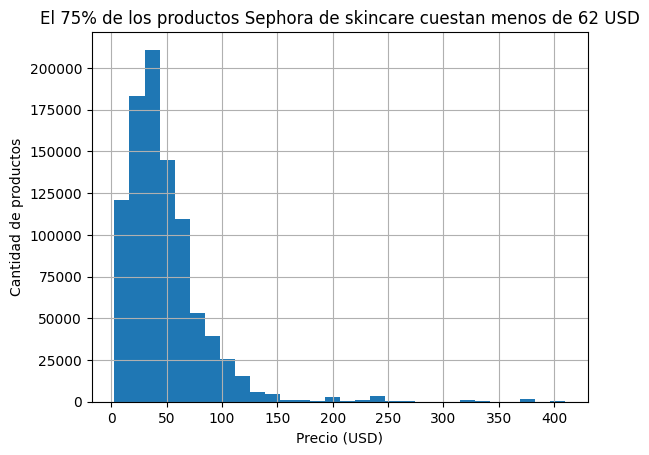

In [ ]:
# Visualizar la distribución de precios de los productos utilizando un histograma
import matplotlib.pyplot as plt

df["price_usd"].hist(bins=30)

plt.title("El 75% de los productos Sephora de skincare cuestan menos de 62 USD")

plt.xlabel("Precio (USD)")

plt.ylabel("Cantidad de productos")

plt.show()

<div style="
background-color:#ffe6f2;
padding:15px;
border-radius:12px;
border-left:6px solid #FF1493;
font-size:15px;
">

<b>📌 Insight:</b><br><br>

El precio promedio de los productos es de aproximadamente 48 USD. 
Además, el 75% de los productos cuesta menos de 62 USD, lo que indica que la mayoría del catálogo se concentra en rangos de precio medios.

Sin embargo, también existen productos premium que alcanzan precios superiores a 400 USD.

</div>

<h2 style="color:#C71585;">
🧴 Productos Más Comentados por los Usuarios
</h2>

Pregunta:
¿Existen productos que destacan significativamente por la cantidad de reviews recibidas?

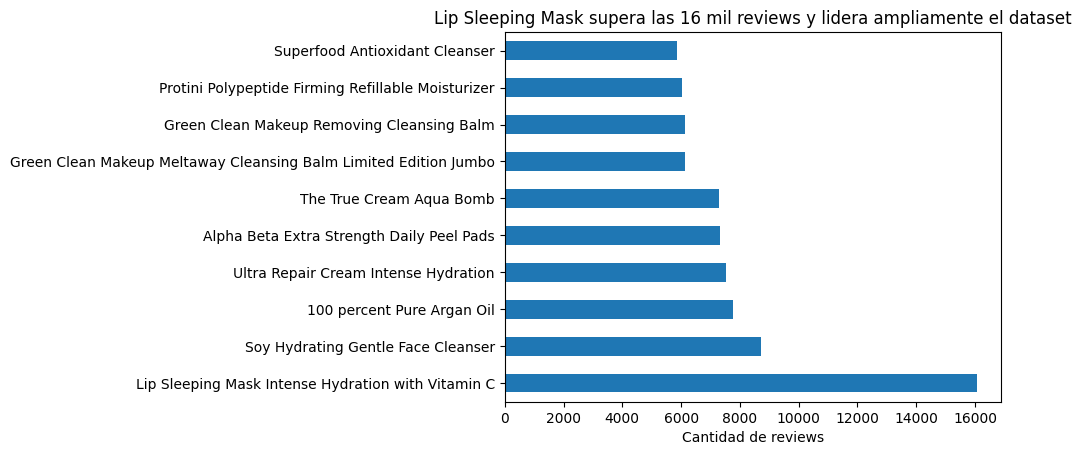

In [ ]:
# Contar la cantidad de reseñas por producto para identificar los más populares y visualizarlo con un gráfico de barras horizontales
top_products_reviews = (
    df["product_name"]
    .value_counts()
    .head(10)
)

top_products_reviews.plot.barh()

plt.title("Lip Sleeping Mask supera las 16 mil reviews y lidera ampliamente el dataset")

plt.xlabel("Cantidad de reviews")

plt.ylabel("")

plt.show()

<div style="
background-color:#ffe6f2;
padding:15px;
border-radius:12px;
border-left:6px solid #FF1493;
">

<b>📌 Insight:</b><br><br>

Las reviews no se distribuyen de manera uniforme entre los productos. 
Algunos productos concentran una cantidad significativamente mayor de reseñas, destacando especialmente “Lip Sleeping Mask Intense Hydration with Vitamin C”, que supera ampliamente al resto del catálogo.

</div>

<h2 style="color:#FF1493;">
🌟 Productos con Mayor Engagement
</h2>

Pregunta:
¿Qué productos generan mayores niveles de engagement entre los usuarios de Sephora?

In [ ]:
# Identificar los productos con mayor engagement (interacción) por usuario que se visualiza en un gráfico de barras horizontales
top_engagement

product_name
Lip Sleeping Mask Intense Hydration with Vitamin C    1081315.0
Niacinamide 10% + Zinc 1% Oil Control Serum            763168.0
Hyaluronic Acid 2% + B5 Hydrating Serum                720504.0
Glycolic Acid 7% Exfoliating Toning Solution           542743.0
AHA 30% + BHA 2% Exfoliating Peeling Solution          533877.0
Lip Glowy Balm                                         471406.0
Protini Polypeptide Firming Refillable Moisturizer     411372.0
Superfood Antioxidant Cleanser                         404142.0
Green Clean Makeup Removing Cleansing Balm             403801.0
Watermelon Glow Niacinamide Dew Drops                  389213.0
Name: loves_count, dtype: float64

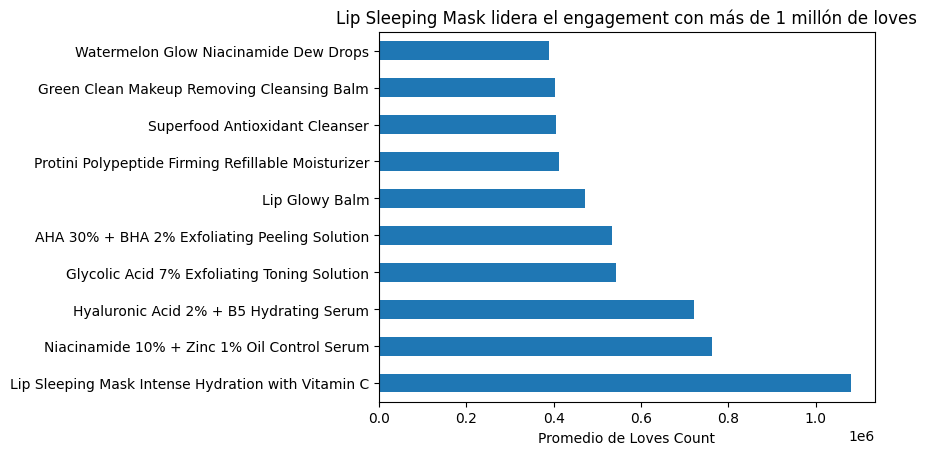

In [ ]:
# Identificar los productos con mayor engagement (interacción) por usuario que se visualiza en un gráfico de barras horizontales
top_engagement = (
    df.groupby("product_name")["loves_count"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_engagement.plot.barh()

plt.title("Lip Sleeping Mask lidera el engagement con más de 1 millón de loves")

plt.xlabel("Promedio de Loves Count")

plt.ylabel("")

plt.show()

<div style="
background-color:#ffe6f2;
padding:15px;
border-radius:12px;
border-left:6px solid #FF1493;
">

<b>📌 Insight:</b><br><br>

El producto con mayor cantidad de reviews también presenta los niveles más altos de engagement. 
Esto sugiere que los productos más comentados dentro del dataset tienden también a ser los más populares entre los usuarios.

</div>

<h2 style="color:#C71585;">
👍 Recomendación de Productos por los Usuarios
</h2>

Pregunta:
¿La mayoría de usuarios recomienda los productos skincare analizados?

In [68]:
# Recomendación de productos basada en la proporción de reseñas y puntuaciones recomendadas por producto visualizada en un gráfico de barras horizontales

recommendation_percentage

Recomendado       84.067762
No recomendado    15.932238
Name: proportion, dtype: float64

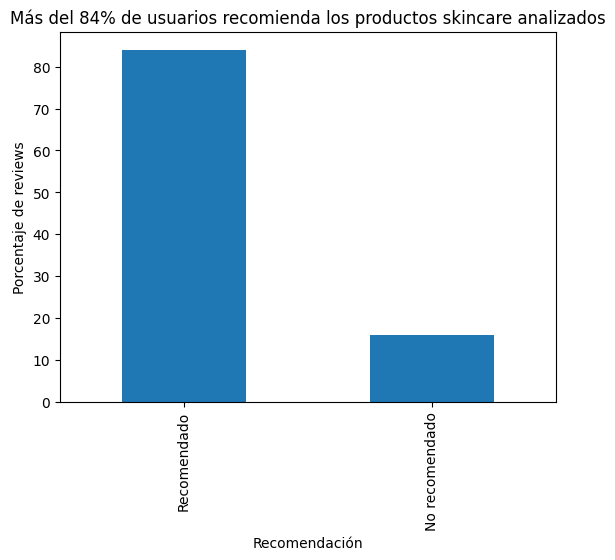

In [ ]:
# Calcular el porcentaje de reseñas recomendadas y no recomendadas para cada producto
recommendation_percentage = (
    df["is_recommended"]
    .value_counts(normalize=True)
    * 100
)

recommendation_percentage.index = [
    "Recomendado",
    "No recomendado"
]

recommendation_percentage.plot.bar()

plt.title("Más del 84% de usuarios recomienda los productos skincare analizados")

plt.xlabel("Recomendación")

plt.ylabel("Porcentaje de reviews")

plt.show()

<div style="
background-color:#ffe6f2;
padding:15px;
border-radius:12px;
border-left:6px solid #FF1493;
">

<b>📌 Insight:</b><br><br>

Los niveles de satisfacción dentro del dataset son altamente positivos. 
Más del 84% de las reviews recomienda los productos skincare analizados, lo que sugiere una percepción general favorable por parte de los usuarios.

</div>

<h2 style="color:#C71585;">
⭐ Precio vs Calificaciones de los Productos
</h2>

Pregunta:
¿Los productos skincare más caros reciben mejores calificaciones por parte de los usuarios?

In [ ]:
# Analizar la correlación entre el precio de los productos y las calificaciones de las reseñas para entender si existe alguna relación entre ambos factores
df[["price_usd", "review_rating"]].corr()

,price_usd,review_rating
price_usd,1.000000,0.002446
review_rating,0.002446,1.000000


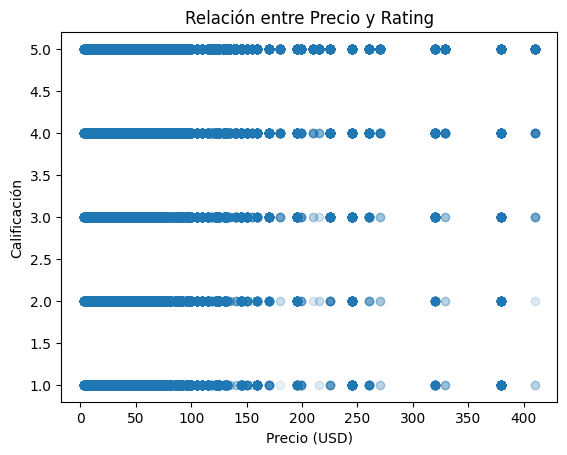

In [ ]:
# Visualizar la relación entre el precio de los productos y las calificaciones de las reseñas utilizando un gráfico de dispersión
plt.scatter(
    df["price_usd"],
    df["review_rating"],
    alpha=0.05
)

plt.title("Relación entre Precio y Rating")

plt.xlabel("Precio (USD)")

plt.ylabel("Calificación")

plt.show()

<div style="
background-color:#ffe6f2;
padding:15px;
border-radius:12px;
border-left:6px solid #FF1493;
">

<b>📌 Insight:</b><br><br>

No se observa una relación significativa entre el precio de los productos y sus calificaciones. 
La correlación entre ambas variables es prácticamente nula (0.002), lo que indica que los productos más caros no necesariamente reciben mejores reviews por parte de los usuarios.

</div>

<h2 style="color:#C71585;">
📅 Evolución de Reviews en el Tiempo
</h2>

Pregunta:
¿Cómo ha evolucionado la actividad de reviews de productos skincare a lo largo del tiempo?

In [ ]:
# visualizar la evolución temporal de las reseñas para identificar tendencias a lo largo del tiempo utilizando un gráfico de líneas
reviews_time.tail()

submission_time
2022-11-30     6974
2022-12-31     8117
2023-01-31    13172
2023-02-28    11951
2023-03-31     9795
Freq: ME, dtype: int64

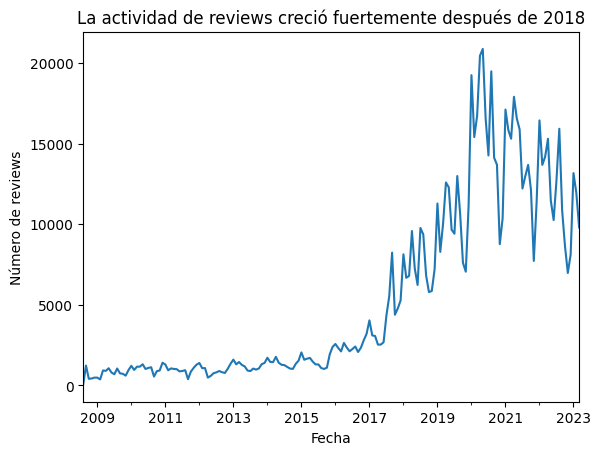

In [ ]:
# Agrupar las reseñas por mes y contar la cantidad de reseñas en cada período para visualizar la evolución temporal
reviews_time = (
    df.set_index("submission_time")
    .resample("ME")
    .size()
)

reviews_time.plot()

plt.title("La actividad de reviews creció fuertemente después de 2018")

plt.xlabel("Fecha")

plt.ylabel("Número de reviews")

plt.show()

<div style="
background-color:#ffe6f2;
padding:15px;
border-radius:12px;
border-left:6px solid #FF1493;
">

<b>📌 Insight:</b><br><br>

La actividad de reviews mostró un crecimiento progresivo a lo largo del tiempo, especialmente después de 2018. 
Entre 2019 y 2021 se observa el mayor volumen de reseñas del dataset, lo que podría indicar un aumento significativo en la interacción de usuarios con productos skincare durante ese periodo.

</div>